# agg_instance notebook walkthrough (dataAdapter datasets)

This walkthrough mirrors the four helper steps exported by `revisions.new_src.agg_instance` while relying on the shared `dataAdapter` loader so you can point the same cells at any supported TU/BA benchmark.


## 0. Configure dataset + import helpers

Change `DATASET_NAME` to another entry from `revisions.new_src.dataAdapter.SUPPORTED_DATASETS` to reuse the exact same flow on a different benchmark. The cell below wires up every helper used later in the notebook.


In [2]:
import sys 
sys.path.append("../")

import torch

from new_src.dataAdapter import load_dataset
from new_src.explainee import fit_explainee
from new_src.agg_instance import (
    build_explainer,
    aggregate_instance_explanations,
    run_eval_summary,
    plot_eval,
)
from new_src.graph_level_dist import spectral_dist
from new_src.simgnn import SimGNN

DATASET_NAME = "MUTAG"  # swap this for any supported dataset
DATA_ROOT = "data"
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = "cpu"

dataset = load_dataset(DATASET_NAME, root=DATA_ROOT)
observed_by_class = dataset.split_by_class()
print(f"Loaded {len(dataset)} graphs from {DATASET_NAME} across {len(observed_by_class)} classes")
print("Class histogram:", {idx: len(split) for idx, split in enumerate(observed_by_class)})


Loaded 188 graphs from MUTAG across 2 classes
Class histogram: {0: 63, 1: 125}


## 1. Train the explainee and configure `torch_geometric.explain.Explainer`

`fit_explainee` trains the shared `GCNClassifier` on whichever dataset you selected. Afterwards `build_explainer` wraps the explainee with the probability adapter and lets you pick any algorithm registered inside `agg_instance` (swap `algorithm` / `algorithm_kwargs` as needed).


In [3]:
explainee, training_stats = fit_explainee(
    DATASET_NAME,
    root=DATA_ROOT,
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    device=DEVICE,
)

explainer = build_explainer(
    explainee,
    algorithm="gnnexplainer",  # try "pgexplainer", Captum variants, etc.
    algorithm_kwargs={"epochs": 50},
    explanation_type="model",
    node_mask_type="object",
    edge_mask_type="object",
)

explainer


[001/30] train_loss=0.5822  val_acc=0.684
[002/30] train_loss=0.5536  val_acc=0.684
[003/30] train_loss=0.5504  val_acc=0.684
[004/30] train_loss=0.5330  val_acc=0.684
[005/30] train_loss=0.5537  val_acc=0.684
[006/30] train_loss=0.5430  val_acc=0.684
[007/30] train_loss=0.5303  val_acc=0.684
[008/30] train_loss=0.5187  val_acc=0.684
[009/30] train_loss=0.5265  val_acc=0.684
[010/30] train_loss=0.5276  val_acc=0.684
[011/30] train_loss=0.5160  val_acc=0.684
[012/30] train_loss=0.5070  val_acc=0.684
[013/30] train_loss=0.4939  val_acc=0.684
[014/30] train_loss=0.4808  val_acc=0.684
[015/30] train_loss=0.4937  val_acc=0.737
[016/30] train_loss=0.4697  val_acc=0.632
[017/30] train_loss=0.4769  val_acc=0.684
[018/30] train_loss=0.4620  val_acc=0.632
[019/30] train_loss=0.4394  val_acc=0.632
[020/30] train_loss=0.4740  val_acc=0.632
[021/30] train_loss=0.4414  val_acc=0.737
[022/30] train_loss=0.4838  val_acc=0.632
[023/30] train_loss=0.4360  val_acc=0.632
[024/30] train_loss=0.4645  val_ac

## 2. Aggregate instance explanations into motif batches

`aggregate_instance_explanations` iterates over the dataset, explains each graph, and groups the salient substructures per predicted class. Select whichever aggregation strategy best matches your study (`"wl_topk"`, `"node_threshold"`, or a custom callable).


In [4]:
aggregation = aggregate_instance_explanations(
    dataset,
    explainer,
    explainee=explainee,
    strategy="wl_topk",
    strategy_kwargs={"wl_hops": 2, "top_p": 0.25, "min_edges": 4},
)

if not aggregation.by_class:
    raise RuntimeError("No motifs detected. Relax the aggregation thresholds or confirm the explainee's accuracy.")

for cls, batch in aggregation.by_class.items():
    print(f"Class {cls}: {batch.num_graphs} motifs, {batch.num_nodes} nodes, {batch.num_edges} edges total")


tensor([[0.7223, 0.2777]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7219, 0.2781]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7217, 0.2783]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7215, 0.2785]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7213, 0.2787]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7212, 0.2788]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7210, 0.2790]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7208, 0.2792]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7206, 0.2794]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7204, 0.2796]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7202, 0.2798]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7200, 0.2800]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7198, 0.2802]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7195, 0.2805]], grad_fn=<SoftmaxBackward0>)
tensor([0, 1])
tensor([[0.7193, 0.2

## 3. Compute the evaluation summary metrics

`run_eval_summary` drops the aggregated motifs plus observed graphs straight into `revisions.new_src.eval.eval_summary`. Here we reuse the ready-made `spectral_dist` module as a graph-level distance, but you can plug in `mcs_soft_graph_dist`, `neural_approx_ged_dist`, or any custom scorer that exposes the same API.


In [ ]:
if len(observed_by_class) < 2:
    raise ValueError("The selected dataset must expose at least two graph classes for eval_summary.")

dist_to_0 = spectral_dist(observed_by_class[0], which="laplacian", k=8)
dist_to_1 = spectral_dist(observed_by_class[1], which="laplacian", k=8)

summary_score = run_eval_summary(
    explainee,
    aggregation,
    observed_class_0=observed_by_class[0],
    observed_class_1=observed_by_class[1],
    dist_to_0=dist_to_0,
    dist_to_1=dist_to_1,
)

print(f"Eval summary score: {summary_score:.4f}")


AttributeError: 'spectral_dist' object has no attribute 'evaluate'

## 4. Plot generated vs observed graphs

`plot_eval` visualises motif batches next to observed graphs while querying a GED approximator. The cell instantiates the shared `SimGNN` architecture so you can immediately load your own checkpoint via `load_state_dict` if you already trained a GED model for the dataset.


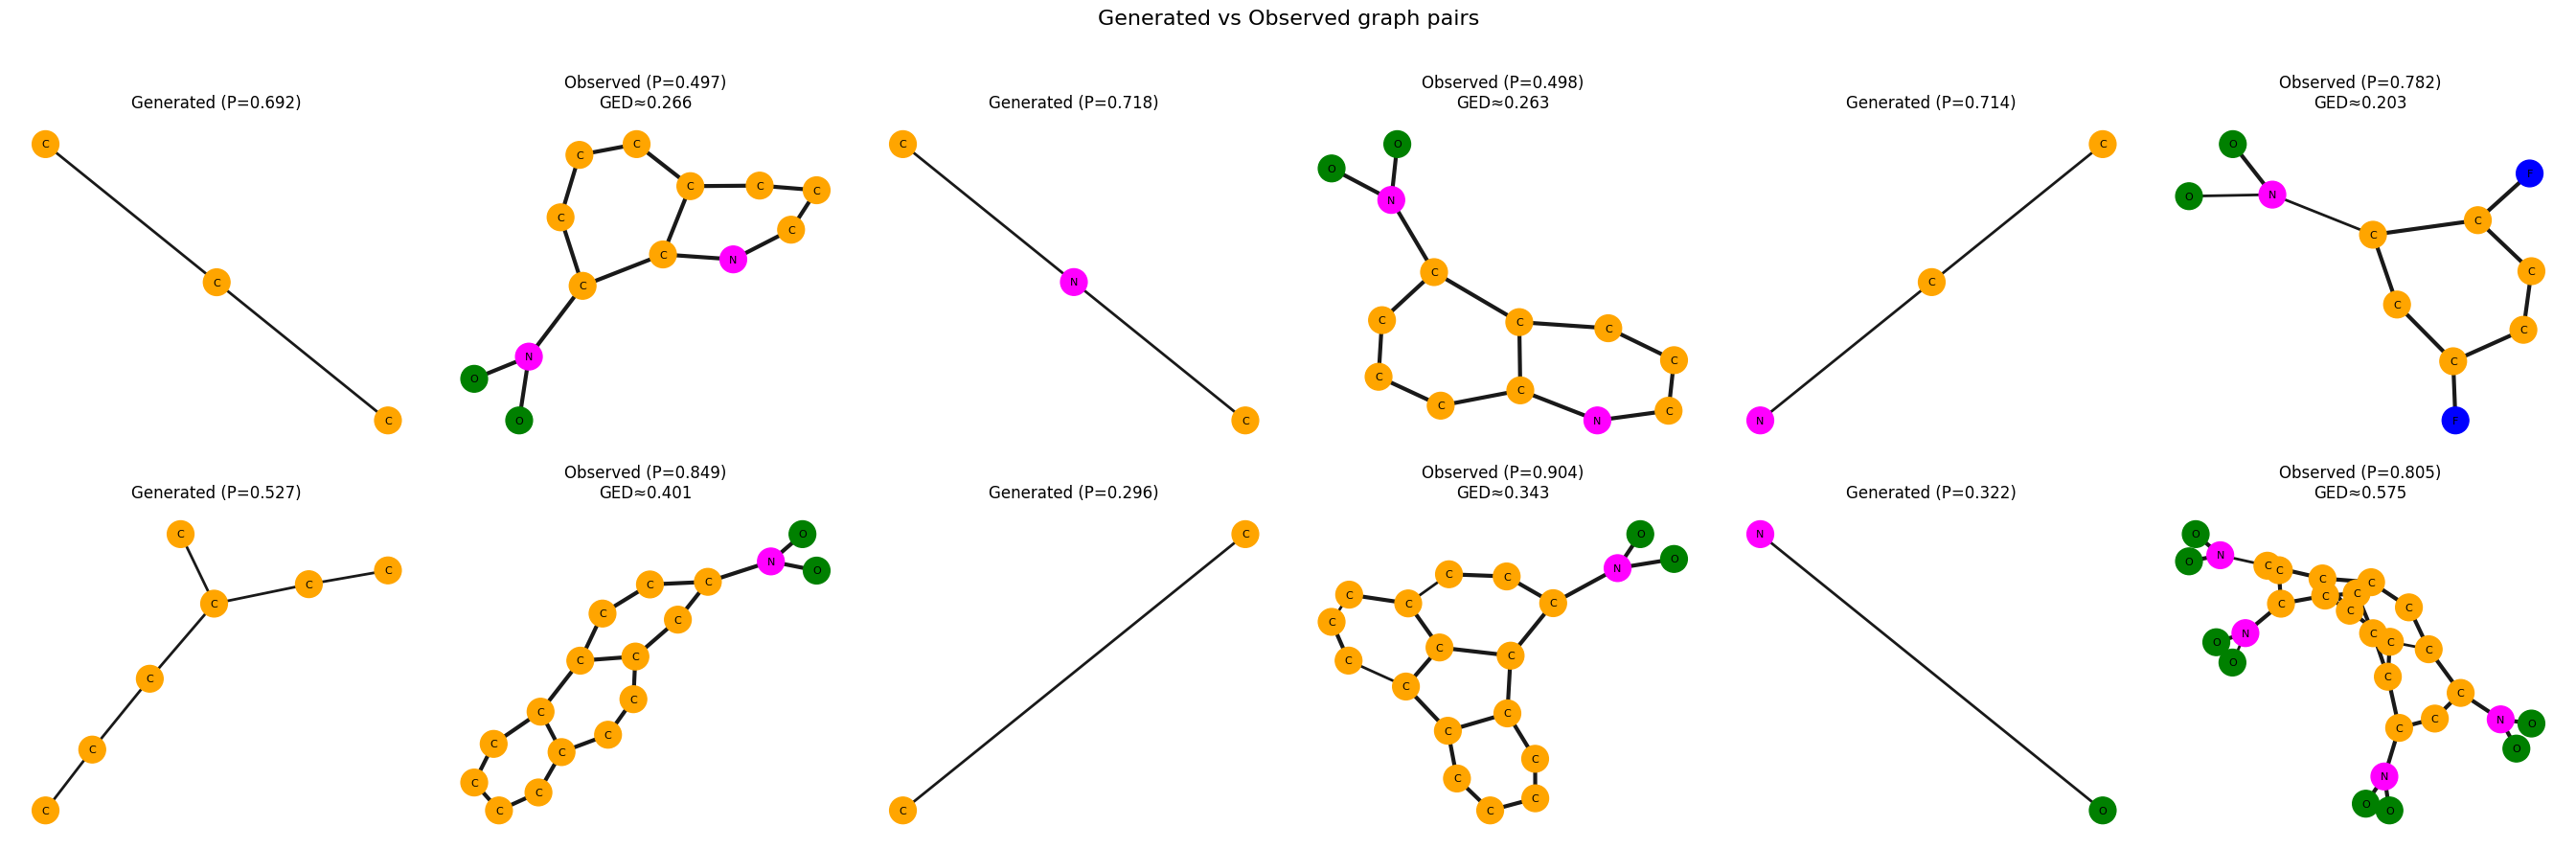

In [6]:
sample_graph = dataset[0]
if getattr(sample_graph, 'x', None) is not None:
    node_feat_dim = sample_graph.x.size(-1) if sample_graph.x.dim() > 1 else 1
else:
    node_feat_dim = max(1, len(getattr(dataset, 'NODE_CLS', {})))

ged_model = SimGNN(
    in_dim=node_feat_dim,
    hidden_dim=64,
    hist_bins=16,
    dropout=0.1,
    use_tensor=False,
    tensor_channels=8,
)

plot_eval(
    explainee,
    aggregation,
    observed_class_0=observed_by_class[0],
    observed_class_1=observed_by_class[1],
    ged_model=ged_model,
    dataset=dataset,
    max_pairs=3,
)
